PCA in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [6]:
iris=load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
y=pd.Series(iris.target,name='target')
print(X)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


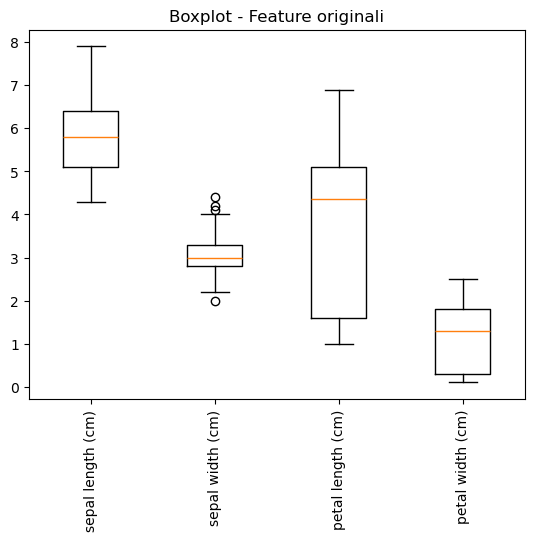

In [17]:
plt.boxplot(X)  #crea un boxplot per ogni feature
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature originali")
plt.show()

Standarizzazione

[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15] [1. 1. 1. 1.]


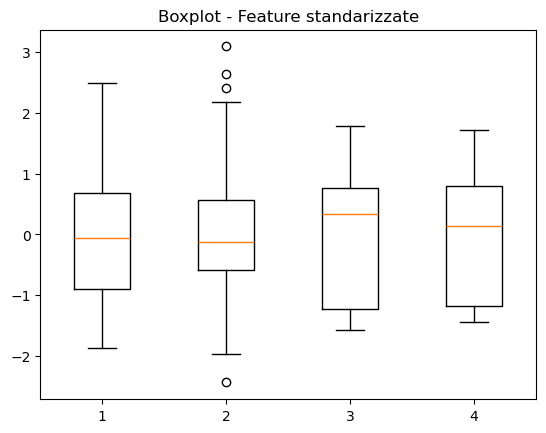

In [ ]:
from matplotlib import axis

scaler=StandardScaler() #StandarScaler rende tutte le variabili (feature) comparabili
X_std=scaler.fit_transform(X)  #standarizzazione z-score

#StandarScaler porta la media a quasi 0 e la deviazione standard a 1
print(X_std.mean(axis=0), X_std.std(axis=0))

plt.boxplot(X_std)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature standarizzate")
plt.show()

PCA per riduzione dimensionale

In [ ]:
#dopo aver applicato la standarizzazione delle feature, posso applicare la PCA per una riduzione dimensionale

pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature (4)
pca.fit(X_std) #trova PC1, PC2, PC3, PC4 con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(exp_var)

[0.72962445 0.22850762 0.03668922 0.00517871]


Visualizzazione grafica

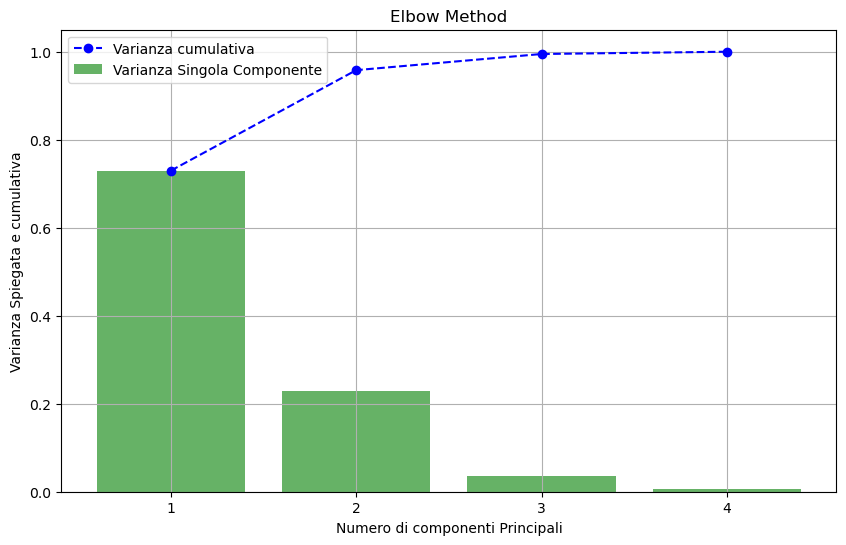

In [16]:
from matplotlib import markers

plt.figure(figsize=(10,6))
plt.plot(range(1,len(cum_var)+1),cum_var,marker="o",linestyle="--",color="b",label="Varianza cumulativa")
plt.bar(range(1,len(exp_var)+1),exp_var,alpha=0.6,color="g",label="Varianza Singola Componente")
plt.grid()
plt.legend()
plt.xticks(range(1,len(cum_var)+1))
plt.xlabel("Numero di componenti Principali")
plt.ylabel("Varianza Spiegata e cumulativa")
plt.title("Elbow Method")
plt.show()

il punto di flesso, il primo punto prima della variazione nella crescita o decrescita della funzione, solo i punti PCA che prendono la maggior parte della varianza. In questo caos 2 componenti.
Il componente n. 1 da quasi il 70% di varianza, mentre il numero 2 circa 20%, quindi sommati sono una buona varianza.
Il numero di componenti ottimale è p?2

In [15]:
p=2
var_retained=cum_var[p-1]
print(f"VAR con p={p}: {(var_retained)*100:.2f} % ({var_retained})")

VAR con p=2: 95.81 % (0.9581320720000164)


In [16]:
pca_final=PCA(n_components=p)
X_pca=pca_final.fit_transform(X_std)
print(f"Dimensione di X_std: \t{X_std.shape}")
print(f"Dimensione di X_pca: \t{X_pca.shape}")

Dimensione di X_std: 	(150, 4)
Dimensione di X_pca: 	(150, 2)


In [28]:
import random
import time

from matplotlib.rcsetup import validate_color_or_auto

n_clusters=3
random_seed=42

kmeams_std=KMeans(n_clusters=n_clusters,random_state=random_seed,n_init='auto')
start_std=time.time()
kmeams_std.fit(X_std)
end_std=time.time()

kmeams_pca=KMeans(n_clusters=n_clusters,random_state=random_seed,n_init='auto')
start_pca=time.time()
kmeams_std.fit(X_pca)
end_pca=time.time()

time_std=round((end_std- start_std) * 1000,3)
time_pca=round((end_pca-start_pca)*1000,0)
print(f"KMeans X_std {time_std} ms")
print(f"KMeans X_pca {time_pca} ms")


KMeans X_std 5.479 ms
KMeans X_pca 3.0 ms


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
